In [1]:
"""
01_eda.ipynb — Exploratory data analysis of NCT-CRC-HE-100K and CRC-VAL-HE-7K.

Produces report figures describing the dataset BEFORE any modeling:
  1. Class distribution across both datasets (bar chart)
  2. Sample H&E patches — one representative per class (3x3 grid)
  3. Image property sanity check (size, mode, file count)

These figures support the Dataset section of the final report and
provide context for interpreting the modeling results in 03_results.ipynb.
"""

from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Paper-quality styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / "data"
TRAIN_DIR    = DATA_DIR / "NCT-CRC-HE-100K"
TEST_DIR     = DATA_DIR / "CRC-VAL-HE-7K"
FIGURES_DIR  = PROJECT_ROOT / "outputs" / "figures"

# Class names — same ordering as ImageFolder uses (alphabetical)
CLASS_NAMES = ["ADI", "BACK", "DEB", "LYM", "MUC", "MUS", "NORM", "STR", "TUM"]

# Sanity check the dataset directories exist
print(f"Train dir: {TRAIN_DIR}  exists: {TRAIN_DIR.exists()}")
print(f"Test dir:  {TEST_DIR}  exists: {TEST_DIR.exists()}")
print(f"Figures dir: {FIGURES_DIR}")

# List class folders to confirm all 9 are present in both datasets
print(f"\nTrain classes found: {sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])}")
print(f"Test classes found:  {sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir()])}")

Train dir: C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project\data\NCT-CRC-HE-100K  exists: True
Test dir:  C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project\data\CRC-VAL-HE-7K  exists: True
Figures dir: C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project\outputs\figures

Train classes found: ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
Test classes found:  ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']


In [2]:
# Count patches per class in each dataset
train_counts = {cls: len(list((TRAIN_DIR / cls).glob("*.tif"))) for cls in CLASS_NAMES}
test_counts  = {cls: len(list((TEST_DIR  / cls).glob("*.tif"))) for cls in CLASS_NAMES}

# Sanity check totals
train_total = sum(train_counts.values())
test_total  = sum(test_counts.values())

print(f"Train dataset (NCT-CRC-HE-100K): {train_total:,} patches")
print(f"Test dataset  (CRC-VAL-HE-7K):  {test_total:,} patches\n")

print(f"{'Class':<6}{'Train':>10}{'Test':>10}")
print("-" * 26)
for cls in CLASS_NAMES:
    print(f"{cls:<6}{train_counts[cls]:>10,}{test_counts[cls]:>10,}")

Train dataset (NCT-CRC-HE-100K): 100,000 patches
Test dataset  (CRC-VAL-HE-7K):  7,180 patches

Class      Train      Test
--------------------------
ADI       10,407     1,338
BACK      10,566       847
DEB       11,512       339
LYM       11,557       634
MUC        8,896     1,035
MUS       13,536       592
NORM       8,763       741
STR       10,446       421
TUM       14,317     1,233


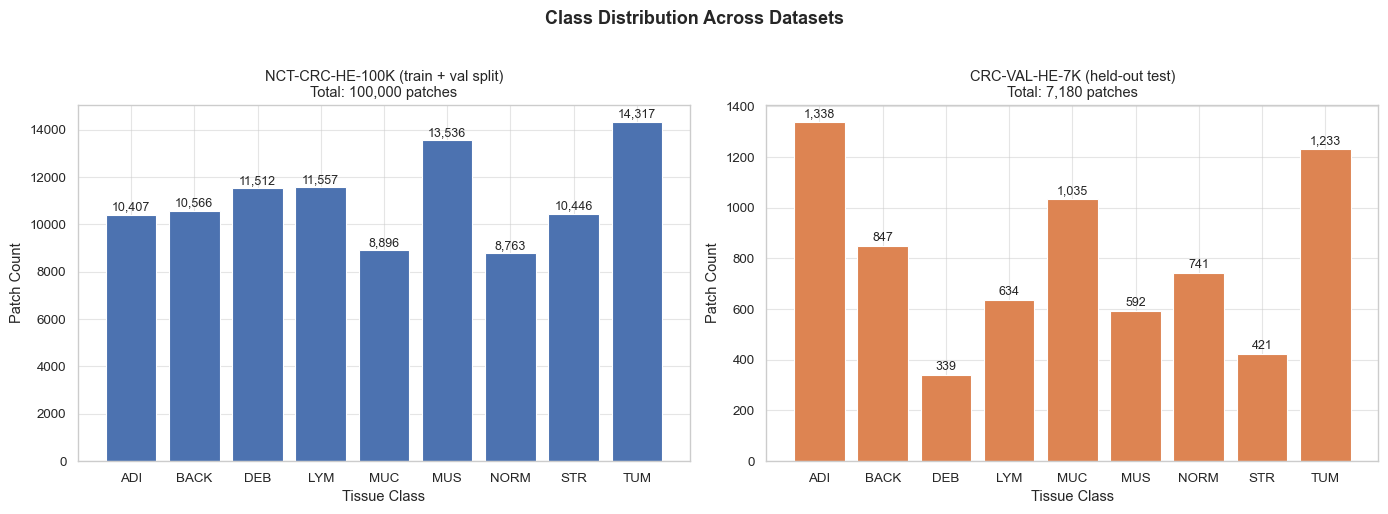

Saved: C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project\outputs\figures\class_distribution.png


In [3]:
# --- Figure: Class distribution across both datasets ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# --- NCT-CRC-HE-100K (train) ---
train_vals = [train_counts[cls] for cls in CLASS_NAMES]
axes[0].bar(CLASS_NAMES, train_vals, color="#4C72B0")
axes[0].set_title(f"NCT-CRC-HE-100K (train + val split)\nTotal: {train_total:,} patches")
axes[0].set_xlabel("Tissue Class")
axes[0].set_ylabel("Patch Count")
for i, v in enumerate(train_vals):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

# --- CRC-VAL-HE-7K (test) ---
test_vals = [test_counts[cls] for cls in CLASS_NAMES]
axes[1].bar(CLASS_NAMES, test_vals, color="#DD8452")
axes[1].set_title(f"CRC-VAL-HE-7K (held-out test)\nTotal: {test_total:,} patches")
axes[1].set_xlabel("Tissue Class")
axes[1].set_ylabel("Patch Count")
for i, v in enumerate(test_vals):
    axes[1].text(i, v + 20, f"{v:,}", ha="center", fontsize=9)

plt.suptitle("Class Distribution Across Datasets", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR / 'class_distribution.png'}")

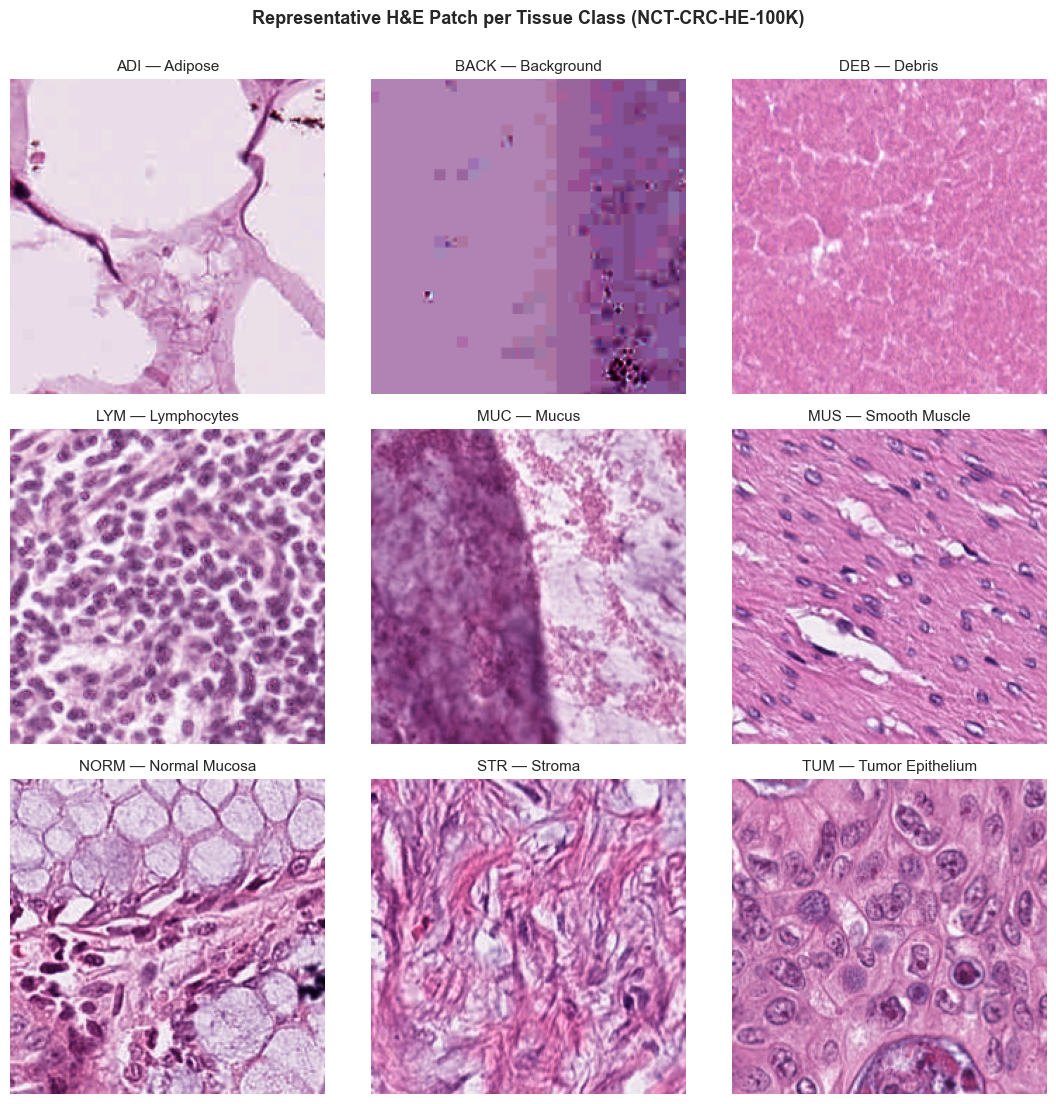

Saved: C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project\outputs\figures\sample_patches.png


In [4]:
# --- Figure: Sample patch per class ---
# Shows one representative H&E patch from each of the 9 classes
# Helps the reader see the visual similarity between STR and MUS (and other confusable pairs)

CLASS_LABELS = {
    "ADI":  "Adipose",
    "BACK": "Background",
    "DEB":  "Debris",
    "LYM":  "Lymphocytes",
    "MUC":  "Mucus",
    "MUS":  "Smooth Muscle",
    "NORM": "Normal Mucosa",
    "STR":  "Stroma",
    "TUM":  "Tumor Epithelium",
}

fig, axes = plt.subplots(3, 3, figsize=(11, 11))

for idx, cls in enumerate(CLASS_NAMES):
    row, col = idx // 3, idx % 3

    # Grab the first .tif file from this class folder
    patch_path = next((TRAIN_DIR / cls).glob("*.tif"))
    img = Image.open(patch_path)

    axes[row, col].imshow(img)
    axes[row, col].set_title(f"{cls} — {CLASS_LABELS[cls]}", fontsize=11)
    axes[row, col].axis("off")

plt.suptitle("Representative H&E Patch per Tissue Class (NCT-CRC-HE-100K)",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_patches.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR / 'sample_patches.png'}")

In [5]:
# --- Image properties sanity check ---
# Verifies that sampled images have expected dimensions, mode, and no corrupted files.
# Checks 1 image per class in both datasets (18 total) — fast.

print("Image Property Sanity Check")
print("=" * 60)
print(f"{'Dataset':<20}{'Class':<8}{'Size':<12}{'Mode':<6}{'Status'}")
print("-" * 60)

all_good = True
for dataset_name, dataset_dir in [("NCT-CRC-HE-100K", TRAIN_DIR), ("CRC-VAL-HE-7K", TEST_DIR)]:
    for cls in CLASS_NAMES:
        patch_path = next((dataset_dir / cls).glob("*.tif"))
        try:
            img = Image.open(patch_path)
            size = f"{img.size[0]}x{img.size[1]}"
            mode = img.mode
            expected = size == "224x224" and mode == "RGB"
            status = "OK" if expected else "UNEXPECTED"
            if not expected:
                all_good = False
            print(f"{dataset_name:<20}{cls:<8}{size:<12}{mode:<6}{status}")
        except Exception as e:
            all_good = False
            print(f"{dataset_name:<20}{cls:<8}{'ERROR':<12}{'-':<6}{str(e)[:30]}")

print("-" * 60)
print(f"\nOverall: {'All images have expected properties (224x224 RGB)' if all_good else 'Some issues detected — see above'}")

Image Property Sanity Check
Dataset             Class   Size        Mode  Status
------------------------------------------------------------
NCT-CRC-HE-100K     ADI     224x224     RGB   OK
NCT-CRC-HE-100K     BACK    224x224     RGB   OK
NCT-CRC-HE-100K     DEB     224x224     RGB   OK
NCT-CRC-HE-100K     LYM     224x224     RGB   OK
NCT-CRC-HE-100K     MUC     224x224     RGB   OK
NCT-CRC-HE-100K     MUS     224x224     RGB   OK
NCT-CRC-HE-100K     NORM    224x224     RGB   OK
NCT-CRC-HE-100K     STR     224x224     RGB   OK
NCT-CRC-HE-100K     TUM     224x224     RGB   OK
CRC-VAL-HE-7K       ADI     224x224     RGB   OK
CRC-VAL-HE-7K       BACK    224x224     RGB   OK
CRC-VAL-HE-7K       DEB     224x224     RGB   OK
CRC-VAL-HE-7K       LYM     224x224     RGB   OK
CRC-VAL-HE-7K       MUC     224x224     RGB   OK
CRC-VAL-HE-7K       MUS     224x224     RGB   OK
CRC-VAL-HE-7K       NORM    224x224     RGB   OK
CRC-VAL-HE-7K       STR     224x224     RGB   OK
CRC-VAL-HE-7K       TUM  